# **Coin Detection, Classification, and Counting**

## Image Processing and Computer Vision - Assignment Module \#1


Contacts:

- Prof. Giuseppe Lisanti -> giuseppe.lisanti@unibo.it
- Prof. Samuele Salti -> samuele.salti@unibo.it
- Alex Costanzino -> alex.costanzino@unibo.it
- Francesco Ballerini -> francesco.ballerini4@unibo.it

## Task
You are given a dataset of photographs containing coins.

Your goal is to build a pipeline that, given an image, detects all coins present, identifies their denomination, and computes the total monetary value shown in the image.

<font color="red"><b>Each step of this assignment must be solved using traditional computer vision techniques.</b></font>

### Example of expected output
```
.
.
.
image_85.jpg - 5 coin(s) found:
  Coin 1 {value: 1.000}
  Coin 2 {value: 0.200}
  Coin 3 {value: 0.100}
  Coin 4 {value: 2.000}
  Coin 5 {value: 0.005}
  Partial Amount {value: 3.350}
image_86.jpg – 3 coin(s) found:
.
.
.

```
<figure>
<a href="https://ibb.co/hxFwbjqg"><img src="https://i.ibb.co/CpKDgZrw/image-85-example.png" alt="image-85-example" border="0"></a>
</figure>

Furthermore, you should provide also the final total amount over all images:
```
.
.
.
Total Amount: TBD €
```

## Data
Two folders of images are provided:
* `reference_set`: eight images, one per coin denomination, each containing a single coin. These images come with a label (their file name is their denomination value) and serve as your reference data. Use them to build and calibrate your classifier;
* `target_set`: a collection of images each containing one or more coins, with no labels. Your pipeline must process each image and output the total monetary value of the coins present.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/drive/MyDrive/LabSessionsIPCV/coin_dataset.zip ./
!unzip coin_dataset.zip

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  coin_dataset.zip
replace __MACOSX/._coin_dataset? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Evaluation criteria
1. **Clarity and conciseness**. Present your work in a readable way: format your code and **comment every important step**;

2. **Procedural correctness**. There are several ways to solve the assignment. Design your own sound approach **and justify every decision you make**;

3. **Results correctness**. Both instance-level and total monetary value will be evaluated. Note that a thoroughly justified and sound procedure with a lower number of solved instances will be valued **more** than a poorly designed and justified approach that solves more or all instances.

<font color="red"><b>Once again, each step of this assignment must be solved using traditional computer vision techniques.</b></font>

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
target_paths = ["coin_dataset/target_set/image_" + str(i) + ".jpg" for i in range(1,143)]
target_set = []
coins_names = ["1cent", "2cent", "5cent", "10cent", "20cent", "50cent", "1euro", "2euro"]
coins_values = [ 0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 1.0, 2.0]
reference_paths = ["coin_dataset/reference_set/" + img + ".jpg"  for img in coins_names]
reference_set = []

for img_path, index in zip(target_paths, range(1,143)):
  img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
  target_set.append(( "image_" + str(index)+".jpg" ,img ))

for img_path, name, value in zip(reference_paths, coins_names, coins_values):
  img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
  reference_set.append((name, img, value))

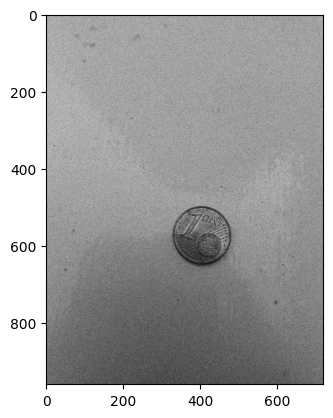

In [ ]:
plt.imshow(target_set[3][1], cmap="gray", vmin=0, vmax=255) # esempio per il target set
plt.show()

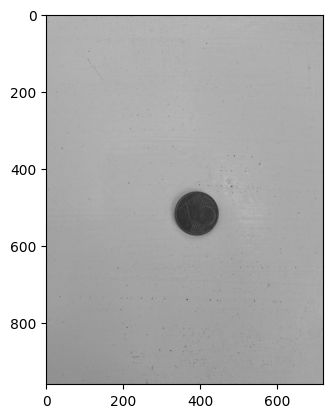

In [ ]:
plt.imshow(reference_set[0][1], cmap="gray", vmin=0, vmax=255) # esempio per il reference set
plt.show()

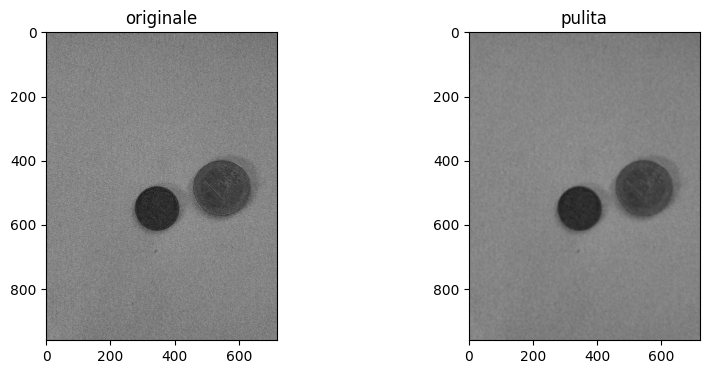

In [ ]:
def preprocess_for_sift(img, med_k=3, bil_d=7, bil_sigmaColor=75, bil_sigmaSpace=25,
                       gauss_k=(3,3), gauss_sigma=0.8, morph_k=3):
    # 1) rimuove sale/pepe
    x = cv2.medianBlur(img, med_k) if med_k > 1 else img.copy()

    # 2) denoise preservando i bordi
    x = cv2.bilateralFilter(x, bil_d, bil_sigmaColor, bil_sigmaSpace)

    # 3) smoothing leggero
    # x = cv2.GaussianBlur(x, gauss_k, gauss_sigma)

    # 4) opening per togliere piccoli puntini di sfondo (stima fondo)
    # kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_k, morph_k))
    # bg = cv2.morphologyEx(x, cv2.MORPH_OPEN, kernel)
    # x = cv2.subtract(x, bg)

   # 5) contrast stretching robusto (2°-98° percentile)
    # p2, p98 = np.percentile(x, (2, 98))
    # if p98 > p2:
    #     x = np.clip((x.astype(np.float32) - p2) * (255.0 / (p98 - p2)), 0, 255).astype(np.uint8)

    return x

# Applica la preprocessing a tutti gli insiemi (non sovrascrive quelli esistenti)
target_set_clean = [(name, preprocess_for_sift(img)) for name, img in target_set]
reference_set_clean = [(name, preprocess_for_sift(img), value) for name, img, value in reference_set]

# Mostra confronto ultimo esempio
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(target_set[-1][1], cmap="gray", vmin=0, vmax=255); plt.title("originale")
plt.subplot(1,2,2); plt.imshow(target_set_clean[-1][1], cmap="gray", vmin=0, vmax=255); plt.title("pulita")
plt.show()

In [ ]:
def extract_coin_rois(img, dp=1.2, minDist=60, param1=100, param2=25,
                      minRadius=20, maxRadius=0, pad_ratio=0.25):
    """
    img: grayscale già preprocessata
    ritorna una lista di dizionari:
        {
            'roi': crop della moneta,
            'mask': maschera binaria del disco,
            'circle': (x, y, r),
            'bbox': (x1, y1, x2, y2)
        }
    """
    h, w = img.shape[:2]

    blur = cv2.GaussianBlur(img, (5, 5), 1.0)

    if maxRadius <= 0:
        maxRadius = min(h, w) // 4

    circles = cv2.HoughCircles(
        blur,
        cv2.HOUGH_GRADIENT,
        dp=dp,
        minDist=minDist,
        param1=param1,
        param2=param2,
        minRadius=minRadius,
        maxRadius=maxRadius
    )

    rois = []

    if circles is None:
        return rois

    circles = np.round(circles[0]).astype(int)

    # ordina da sinistra a destra, oppure puoi ordinare per raggio
    circles = sorted(circles, key=lambda c: (c[1], c[0]))

    for (x, y, r) in circles:
        pad = int(r * pad_ratio)

        x1 = max(0, x - r - pad)
        y1 = max(0, y - r - pad)
        x2 = min(w, x + r + pad)
        y2 = min(h, y + r + pad)

        roi = img[y1:y2, x1:x2].copy()

        mask = np.zeros_like(roi, dtype=np.uint8)
        cx = x - x1
        cy = y - y1
        cv2.circle(mask, (cx, cy), r, 255, -1)

        rois.append({
            "roi": roi,
            "mask": mask,
            "circle": (x, y, r),
            "bbox": (x1, y1, x2, y2)
        })

    return rois


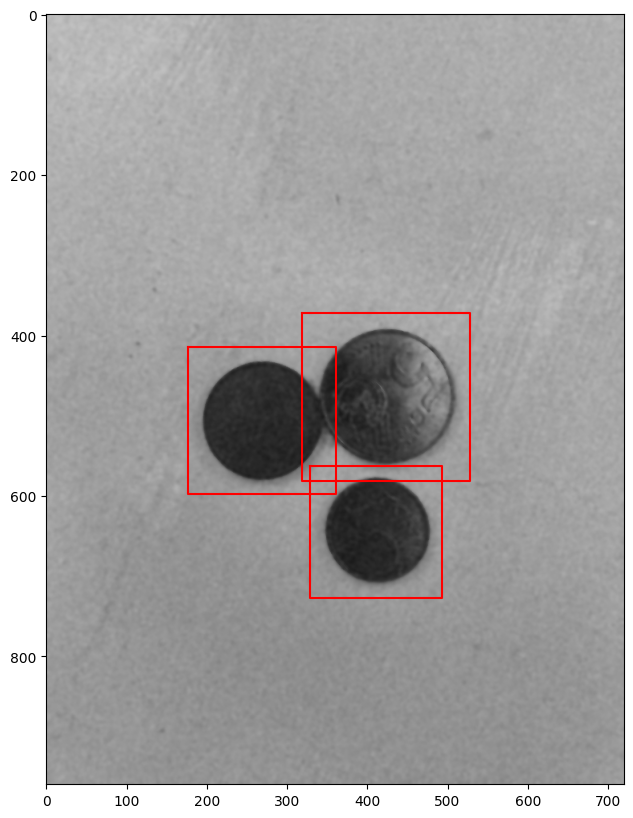

In [ ]:
# stampa un'immagine per ogni regione di interesse trovata
def show_rois(rois, img):
    plt.figure(figsize=(10,10))
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    for roi in rois:
        x1, y1, x2, y2 = roi["bbox"]
        plt.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], "r")
    plt.show()
# invoca la funzione
rois = extract_coin_rois(target_set_clean[0][1])
show_rois(rois, target_set_clean[0][1])

In [ ]:
target_rois = []

for name, img in target_set_clean:
    rois = extract_coin_rois(img)
    target_rois.append((name, img, rois))

In [ ]:
reference_rois = []

for name, img, value in reference_set_clean:
    roi = extract_coin_rois(img)[0]
    reference_rois.append((name, img, value, roi))

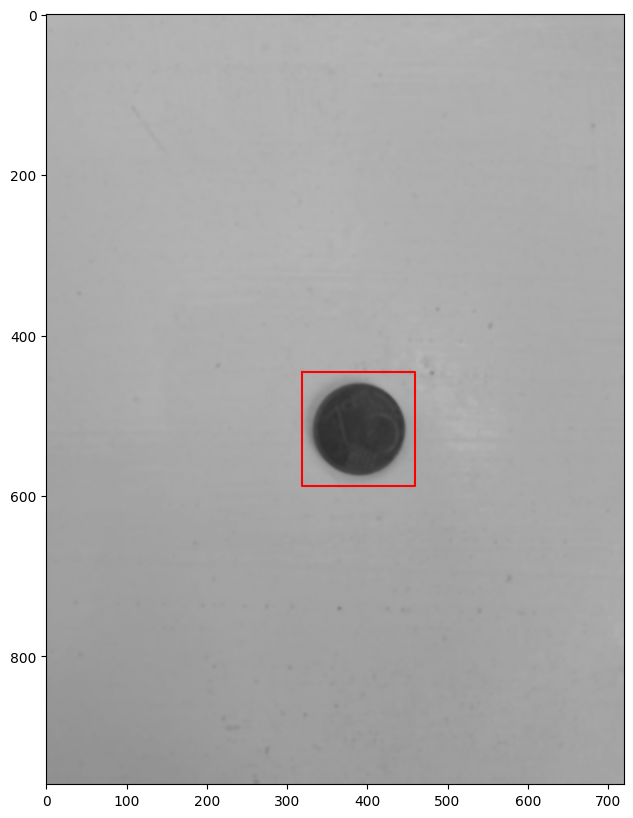

In [ ]:
show_rois([reference_rois[0][3]], reference_rois[0][1])

In [ ]:
# Initiate SIFT detector
sift = cv2.SIFT_create()

In [ ]:
def apply_disk_mask(roi, mask):
    out = roi.copy()
    out[mask == 0] = 0
    return out

In [ ]:
target_models = []

for name, img, rois in target_rois:
    roi_models = []
    for obj in rois:
        roi_img = apply_disk_mask(obj["roi"], obj["mask"])
        kp, des = sift.detectAndCompute(roi_img, None)
        roi_models.append({
            "circle": obj["circle"],
            "bbox": obj["bbox"],
            "roi": roi_img,
            "kp": kp,
            "des": des
        })
    target_models.append((name, roi_models))

In [ ]:
reference_models = []

for name, img, value, roi in reference_rois:
    roi_img = apply_disk_mask(roi["roi"], roi["mask"])
    kp, des = sift.detectAndCompute(roi_img, None)
    roi_model = {
        "circle": roi["circle"],
        "bbox": roi["bbox"],
        "roi": roi_img,
        "kp": kp,
        "des": des
    }
    reference_models.append((name, roi_model))

In [ ]:
des_ref = reference_models[3][1]['des']      # 10cent(quarto reference), prima ROI
des_tgt = target_models[1][1][0]['des']         # 10cent (secondo target), prima ROI

FLANN_INDEX_KDTREE = 1

index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)

matches = flann.knnMatch(
    des_ref.astype(np.float32),
    des_tgt.astype(np.float32),
    k=2
)

good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

In [ ]:
good

[< cv2.DMatch 0x7cd9e7a13310>,
 < cv2.DMatch 0x7cd9e7a12b90>,
 < cv2.DMatch 0x7cd9e7013630>]

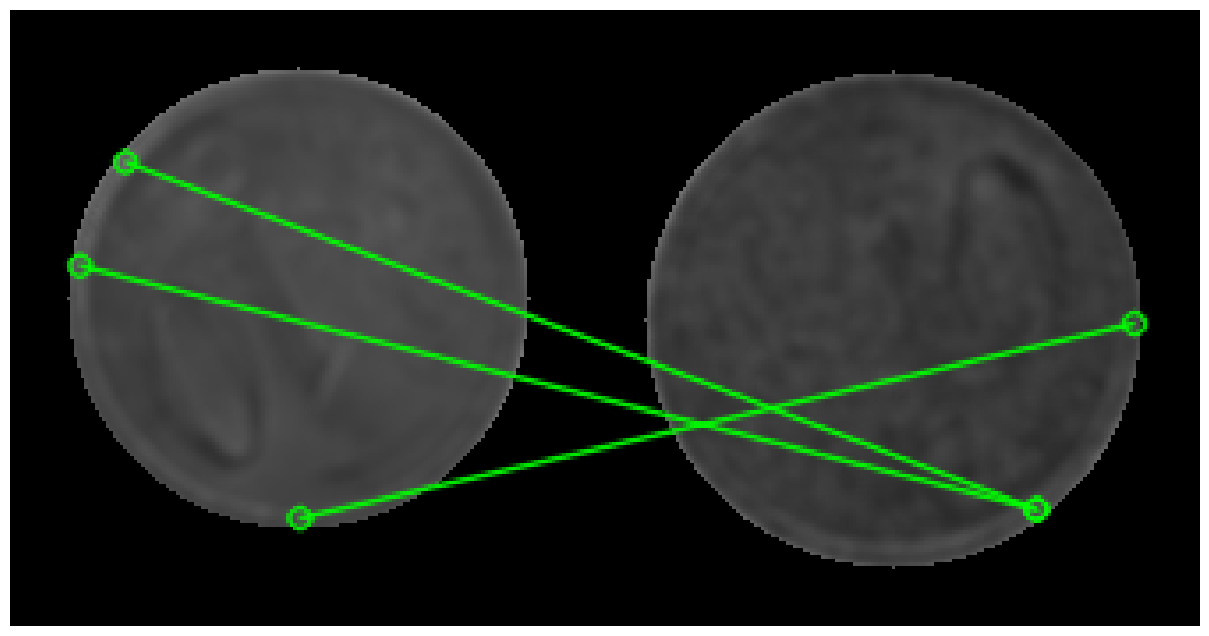

In [ ]:
# Seleziona la coppia di ROI su cui hai calcolato i match
ref_idx = 3   # esempio: reference_models[3]
tgt_idx = 1   # esempio: target_models[1]
roi_idx = 0   # prima ROI trovata nell'immagine target

ref_roi = reference_models[ref_idx][1]["roi"]
ref_kp = reference_models[ref_idx][1]["kp"]

tgt_roi = target_models[tgt_idx][1][roi_idx]["roi"]
tgt_kp = target_models[tgt_idx][1][roi_idx]["kp"]

# Disegno dei match
draw_params = dict(
    matchColor=(0, 255, 0),
    singlePointColor=None,
    flags=2
)

img3 = cv2.drawMatches(ref_roi, ref_kp, tgt_roi, tgt_kp, good, None, **draw_params)

plt.figure(figsize=(16, 8))
plt.imshow(img3)
plt.axis("off")
plt.show()

In [ ]:
# Assumi che esistano:
# - reference_models: list of (name, roi_model) where roi_model has 'kp' and 'des'
# - target_models: list of (img_name, [roi_model,...]) where roi_model has 'kp' and 'des'
# Output richiesto: lista di tuple (image_name, rois_list)
# where rois_list[i] is a list of length len(reference_models) with the good matches for each reference.

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=10)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
ratio_test = 0.75

all_results = []
n_refs = len(reference_models)

for tgt_name, roi_models in target_models:
    rois_matches = []
    for roi_model in roi_models:
        tgt_des = roi_model.get('des', None)
        per_ref = []
        for ref_name, ref_model in reference_models:
            ref_des = ref_model.get('des', None)
            # handle missing descriptors or descriptors with less than k=2 features
            if (ref_des is None) or (tgt_des is None) or len(ref_des) < 2 or len(tgt_des) < 2:
                per_ref.append([])  # no matches
                continue
            # FLANN expects float32
            matches = flann.knnMatch(ref_des.astype(np.float32), tgt_des.astype(np.float32), k=2)
            good = []
            for m, n in matches:
                if m.distance < ratio_test * n.distance:
                    good.append(m)
            per_ref.append(good)
        # ensure exactly n_refs entries
        if len(per_ref) < n_refs:
            per_ref += [[]] * (n_refs - len(per_ref))
        rois_matches.append(per_ref)
    all_results.append((tgt_name, rois_matches))

# all_results is the requested structure:
# - all_results[i][0] -> image name
# - all_results[i][1] -> list of ROIs
# - all_results[i][1][r_idx] -> for ROI r_idx, a list (length n_refs) of good-match lists
print(f"Computed matches for {len(all_results)} target images.")
# Esempio accesso: all_results[0][1][roi_idx][ref_idx] -> list di cv2.DMatch

Computed matches for 142 target images.


In [ ]:
coins_names = ["1cent", "2cent", "5cent", "10cent", "20cent", "50cent", "1euro", "2euro"]

# Raccogli dati per la tabella
data = []
for img_idx, (img_name, rois_matches) in enumerate(all_results):
    for roi_idx, per_ref_matches in enumerate(rois_matches):
        match_counts = [len(good) for good in per_ref_matches]
        total = sum(match_counts)
        best_ref = coins_names[match_counts.index(max(match_counts))] if match_counts else "N/A"

        row = {
            "Image": img_name,
            "ROI": roi_idx + 1,
        }
        # Aggiungi i conteggi per ogni reference
        for ref_idx, count in enumerate(match_counts):
            row[coins_names[ref_idx]] = count

        row["Total"] = total
        row["Best"] = best_ref
        data.append(row)

df = pd.DataFrame(data)
print(df.to_string(index=False))

        Image  ROI  1cent  2cent  5cent  10cent  20cent  50cent  1euro  2euro  Total   Best
  image_1.jpg    1      1      0      2       0       0       0      0      0      3  5cent
  image_1.jpg    2      0      0      0       0       0       0      0      0      0  1cent
  image_1.jpg    3      3      0      3       1       0       1      1      0      9  1cent
  image_2.jpg    1      3      0      5       3       0       1      3      1     16  5cent
  image_3.jpg    1      3      0      5       2       1       1      0      1     13  5cent
  image_3.jpg    2      0      0      0       1       1       0      0      0      2 10cent
  image_3.jpg    3      3      0      5       5       2       1      2      3     21  5cent
  image_3.jpg    4      2      0      0       0       0       0      0      1      3  1cent
  image_3.jpg    5      0      0      0       1       0       0      0      0      1 10cent
  image_3.jpg    6      2      0      1       1       0       0      1      0   

In [ ]:
# # Checking if enough matches are found
# MIN_MATCH_COUNT = 5                          # nel progetto questo è un iperparametro che possiamo cambiare un po'

# if len(good) > MIN_MATCH_COUNT:
#     # Building the correspondence arrays of good matches
#     src_pts = np.float32([reference_models[0][3][m.queryIdx].pt for m in good]).reshape(-1, 1, 2)   # da mettere tutte le reference
#     dst_pts = np.float32([target_models[3][2][m.trainIdx].pt for m in good]).reshape(-1, 1, 2)      # da mettere tutti i target
#     # Using RANSAC to estimate a robust homography.
#     # It returns the homography M and a mask for the discarded points.
#     M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

#     # Mask of discarded point used in visualization
#     matches_mask = mask.ravel().tolist()

#     # Corners of the model image
#     h, w = target_models[6][1].shape
#     pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

#     # Projecting the corners into the scene image
#     dst = cv2.perspectiveTransform(pts, M)

#     # Drawing the bounding box
#     img_train_p = cv2.polylines(reference_models[6][1],[np.int32(dst)], True, 255, 3, cv2.LINE_AA)

# else:
#     print(f"Not enough matches are found - {len(good)}/{MIN_MATCH_COUNT}")
#     matches_mask = None

Not enough matches are found - 2/5


In [ ]:
# Possibili cose da fare:
- ransac
- rimettere i colori
- canny
- potremmo provare a mugliorare la pulizia?
- provare a usare piu immagini contemporaneamente (piu filtri) non